<a href="https://colab.research.google.com/github/victorm0202/temas_selectos_CD_2026/blob/main/01_Data_integration_and_processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Tutorial: Data integration for microbiome research using scikit-bio**


# Section 01: Working with the Earth Microbiome Project (40 min)


Welcome to the practical session 01. created by professor Qiyun Zhu for ISCB Workshop and adapted by Nelly Selem.

---

## Background
Microbiomes are complex ecosystems whose composition and dynamics shape the health of organisms and environments. Recent advances in artificial intelligence (AI) and machine learning have transformed our ability to interpret these communities from massive sequencing data. Characterizing these communities involves: i) integrating diverse high-throughput omic datasets, including  [Metagenomics](https://en.wikipedia.org/wiki/Metagenomics), and ii) Classification algorithms, that serve as foundational analytical tools to classify and interpret complex biological data.

Clustering algorithms function by grouping elements based on their intrinsic similarity. In microbial ecology, this concept manifests in clustering taxa through phylogenetic trees and comparing community compositions via beta diversity metrics.

As an example of clustering this session uses metagenomic data from a real-world study -- the **Earth Microbiome Project 500** ([EMP500](https://earthmicrobiome.org/emp500/)), an expansive global survey that captures microbial diversity across diverse environments, providing an ideal framework to practice data integration and analysis techniques.


🏆 QUESTIONS

Why are important microbiomes studies?

Why is important to understand the format files in biologic data?

🎯 AIMS

1. Utilize Google Colab as a cloud-based environment to ensure reproducible and scalable bioinformatic workflows.

2. Manipulate heterogeneous data formats (TSV, BIOM, taxa, Newick) to construct harmonized data tables for downstream computational analyses.


🔑 KEY POINTS

*   Colab notebook allows code reproducibility in the cloud.
*   EMP500 is a research project on global microbial diversity.
*   Shotgun metagenomcis include metabolic information.
*   Metadata such as emp01, empo_2 are stored in file with format tsv or csv.
*   Representation of phylogenetic trees in Newick format.

---
📥 **Input: Multi-omic dataset from EMP500 project
  
  Sample metadata: Sample.tsv

  Metagenomic feature tables:

    ogu.biom (BIOM format for feature abundance)

    ogu.tax (taxonomy annotations)

    ogu.nwk (phylogenetic tree in Newick format)

📤 Output:

  Subset data from Latin American samples.

    

## To know more: Webinar  “Applications of artificial intelligence for biosciences in Latin America"
 If you want to know more about about microbiomes and Artificial Intelligence watch this video [Artificial intelligence for exploring and understanding microbiomes](https://www.ebi.ac.uk/training/events/artificial-intelligence-exploring-and-understanding-microbiomes/).


## Preparation (7 min - 8:10)

Install the latest version of scikit-bio if it hasn't been (needed for every Google Colab instance).

In [ ]:
from importlib.util import find_spec

In [ ]:
if find_spec('skbio') is None:

    !pip install -q scikit-bio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 93.6 MB/s eta 0:00:00


Installation of skbio (cell [2]) takes approx 3 minutes. It is recomended to run inmediatly after starting the workshop, while the instructor explains the following cells.

In [ ]:
import skbio
skbio.__version__

'0.7.2'

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## The EMP500 study (10 min - 8:20)

A `README.md` file within the data directory provides basic information about the study. Take a quick look at it:

The EMP500 project was described in the following paper:

- https://www.nature.com/articles/s41564-022-01266-x

In this work, the researchers performed multi-omic analyses of **880** samples collected from various free-living and host-associated environments across the Earth. They conducted amplicon sequencing (16S, 18S, ITS), shotgun metagenomics (and subsequent assembly), and untargeted metabolomics (LC-MS and GC-MS). Through the integration of these omic data types and sample traits, they identified the generic and environment-specific associations between microbes and metabolites.

![image.png](https://github.com/nselem/biotraintemp/blob/main/figures/EMP.png?raw=true)

_**Fig. 1**: The 880 EMP500 samples: environmental classification and geographical locations. Linked from Fig. 1 of [Shaffer et al. (2022)](https://www.nature.com/articles/s41564-022-01266-x)._

### Sample metadata

[**Metadata**](https://en.wikipedia.org/wiki/Metadata) provides information about other data. In an omic study, the properties of the biological samples, specimens, subjects, etc. are usually provided by the **sample metadata**. Examples including demographics, morphology, behaviors, clinical measurements, etc. Sample metadata is the most essential component of an omic study, and should be treated in priority over any omic data. Without metadata, one is left with numbers but without any biological question to address.

- Meanwhile, there are **feature metadata** -- the information about biological entities studied in each omic. They will be discussed below.

The sample metadata table, `sample.tsv`, is a tab-separated values ([TSV](https://en.wikipedia.org/wiki/Tab-separated_values)) file with samples as rows and properties as columns. Let's take a peek at the table:

In [ ]:
github_data_path = "https://raw.githubusercontent.com/nselem/biotraintemp/refs/heads/main/data/"

In [ ]:
metadata_path = github_data_path + "emp500/sample.tsv"
metadata_path

'https://raw.githubusercontent.com/nselem/biotraintemp/refs/heads/main/data/emp500/sample.tsv'

In [ ]:
sample_df = pd.read_csv(metadata_path, sep='\t', low_memory=False, index_col='sample_name')
sample_df.head()

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s004,Angenent65.misc.1022,bioreactor sludge,02/12/2014 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s005,Angenent65.misc.1538,bioreactor sludge,7/13/15 0:00,USA - New York,not applicable,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.1538,not applicable,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


### SampleMetadada Class



```
# Esto tiene formato de código
```

Meanwhile, scikit-bio provides a specific class: [`SampleMetadata`](https://scikit.bio/docs/latest/generated/skbio.metadata.SampleMetadata.html), for handling sample metadata. This class was ported from [QIIME 2](https://qiime2.org/), a widely adopted platform for microbiome data analysis. If you are already familiar with QIIME 2, you may find this class familiar as well. skbio team is working to expand its functionality beyond what was already offered. Now we will convert sample_df dataframe to SampleMetadata from skbio  



In [ ]:
from skbio.metadata import SampleMetadata

An advantage of `SampleMetadata` is that it implements pre-defined rules for parsing biological metadata. For example, [missing data](https://en.wikipedia.org/wiki/Missing_data) are prevalent in biological research. They can occur for multiple reasons, which should be noted rather than leaving the cells empty. The International Nucleotide Database Collaboration (INSDC, https://www.insdc.org/) defined terms representing different types of missing data, such as "not applicable", "not collected", "not provided" and "restricted access" (linked below).

- https://www.insdc.org/submitting-standards/missing-value-reporting/

In [ ]:
meta = SampleMetadata(sample_df, default_missing_scheme='INSDC:missing')
meta

SampleMetadata
--------------
880 IDs x 33 columns
sample_name_original:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
sample_type:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
collection_timestamp:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
country:                       ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
depth_sample:                  ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
description:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
elevation:                     ColumnProperties(type='numeric', missing_scheme='INSDC:missing')
emp500_principal_investigator: ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
emp500_study_id:               ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
emp500_pi_study_id:            ColumnProperties(type=

This table can be loaded using Pandas, and scikit-bio fully supports the analysis of Pandas dataframes.

One can extract a metadata column by its name. The output is a [`MetadataColumn`](https://scikit.bio/docs/latest/generated/skbio.metadata.MetadataColumn.html) object.

For example, column `empo_2` describes the level 2 EMP Ontology ([EMPO](https://earthmicrobiome.org/protocols-and-standards/empo/)) of the environment from which the sample was collected.


In [ ]:
empo_2 = meta.get_column('empo_2') # Use latam_samples, which is a SampleMetadata object
empo_2

<CategoricalMetadataColumn name='empo_2' id_count=880>

Likewise, a metadata column can be converted into a Pandas series

In [ ]:
s_empo_2= empo_2.to_series()
s_empo_2

,empo_2
sample_name,
13114.angenent.65.s001,Animal
13114.angenent.65.s002,Animal
13114.angenent.65.s003,Animal
13114.angenent.65.s004,Animal
13114.angenent.65.s005,Animal
...,...
13114.zaneveld.9.s018,Animal
13114.zaneveld.9.s019,Animal
13114.zaneveld.9.s020,Animal


Using Pandas, one can further explore the distrubution of values

In [ ]:
empo_2_freqs = s_empo_2.value_counts()
empo_2_freqs

,count
empo_2,
Non-saline,343
Animal,301
Plant,115
Saline,109
Fungus,12


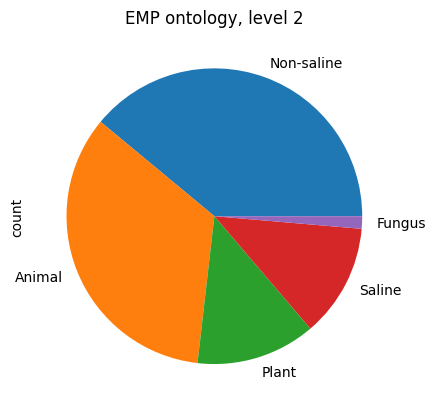

In [ ]:
empo_2_freqs.plot.pie(title='EMP ontology, level 2');

We finalice this section by pointing that a samplemetadata object can also be converted into a pandas dataframe with:

In [ ]:
df_metadata= meta.to_dataframe()
df_metadata.head(5)

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.angenent.65.s001,Angenent65.misc.104,bioreactor sludge,08/09/2011 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s002,Angenent65.misc.519,bioreactor sludge,9/27/12 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s003,Angenent65.misc.946,bioreactor sludge,11/28/13 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.104,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s004,Angenent65.misc.1022,bioreactor sludge,02/12/2014 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.519,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome
13114.angenent.65.s005,Angenent65.misc.1538,bioreactor sludge,7/13/15 0:00,USA - New York,NaN,Corn Beer Fermentation Bioreactor Biomass,123.0,Angenent,65,Angenent65,...,anaerobic bioreactor,anaerobic sludge,host-associated,United States of America:State of New York:Cit...,LTA.misc.1538,NaN,42.44,-76.5,Corn Beer Fermentation Bioreactor,bioreactor metagenome


## Filtering metadata from **Latino America** (7 min - 8:30)

#### Exercise # 1 Filtering data from latinoamerica (begginners)

Ask the colab IA to filter latinamerica metadata for you.
1. Push the +code (+código) button to generate a new cell
2. Click on generate (generar) with IA
3. Add the following text to the cell "Please filter from df_metadata object keeping only those samples that were collected in latam_countries"
4. Run the cell (control + enter)


<details>
  <summary> Click here to see the solution</summary>
<h3>Answer to exercise</h3>
You should get 92 rows, corresponding to Latinamerica samples.   
After doing th excercise, even If it did not run, just keep runing the next cells ( runing the next cell will solve the exercise securing that everybody will have the same code)
</details>



In [ ]:
# prompt: lease filter from df_metadata object keeping only those samples that were collected in latam_countries"

latam_countries = ["Argentina", "Brazil", "Chile", "Colombia", "Ecuador", "Mexico", "Peru", "Uruguay", "Venezuela"]
latam_metadata = df_metadata[df_metadata['country'].isin(latam_countries)]
latam_metadata.head()

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.jensen.43.s012,Jensen43.MX12.189,sediment,07/02/2012,Mexico,15,Jensen43.sediment.11,0.0,Jensen,43,Jensen43,...,marine subtidal rocky reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-189,NaN,21.023610,-86.77158,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s013,Jensen43.MX12.213,sediment,07/04/2012,Mexico,15,Jensen43.sediment.12,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-213,NaN,20.331940,-87.02712,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s014,Jensen43.MX12.236,sediment,07/05/2010,Mexico,15,Jensen43.sediment.14,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-236,NaN,18.759170,-87.34052,Jensen sediments from global ocean,marine sediment metagenome
13114.rohwer.86.s001,Rohwer86.microbial.mat.MGN1,microbial mat,2002,Mexico,0,microbial mat (Lyngbya sp.) from Guerrero Negr...,0.0,Rohwer,86,Rohwer86,...,microbial mat,biofilm,microbial mat/biofilm,Mexico:State of Baja California Sur:Guerrero N...,MGN1,NaN,27.800000,-114.05000,Mexico mats and sediment,microbial mat metagenome
13114.rohwer.86.s002,Rohwer86.sediment.BBS1,sediment,2005,Mexico,0,"sediment from Cuatro Cienegas Basin, Mexico",0.0,Rohwer,86,Rohwer86,...,marine benthic feature,sediment,sediment,Mexico:State of Coahuila de Zaragoza:Cuatro Ci...,BBS1,NaN,26.916667,-102.10000,Mexico mats and sediment,sediment metagenome


Subsetting latin America samples
For this Workshop we will only use  samples from **Latin America**, so we will select the Latino America countries for data filtering. Next we create a list of latinamerican countries.

In [ ]:
# Filter df_metadata to keep only samples from latam_countries
latam_metadata = df_metadata[df_metadata['country'].isin(latam_countries)]
latam_metadata.head()

,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.jensen.43.s012,Jensen43.MX12.189,sediment,07/02/2012,Mexico,15,Jensen43.sediment.11,0.0,Jensen,43,Jensen43,...,marine subtidal rocky reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-189,NaN,21.023610,-86.77158,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s013,Jensen43.MX12.213,sediment,07/04/2012,Mexico,15,Jensen43.sediment.12,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-213,NaN,20.331940,-87.02712,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s014,Jensen43.MX12.236,sediment,07/05/2010,Mexico,15,Jensen43.sediment.14,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-236,NaN,18.759170,-87.34052,Jensen sediments from global ocean,marine sediment metagenome
13114.rohwer.86.s001,Rohwer86.microbial.mat.MGN1,microbial mat,2002,Mexico,0,microbial mat (Lyngbya sp.) from Guerrero Negr...,0.0,Rohwer,86,Rohwer86,...,microbial mat,biofilm,microbial mat/biofilm,Mexico:State of Baja California Sur:Guerrero N...,MGN1,NaN,27.800000,-114.05000,Mexico mats and sediment,microbial mat metagenome
13114.rohwer.86.s002,Rohwer86.sediment.BBS1,sediment,2005,Mexico,0,"sediment from Cuatro Cienegas Basin, Mexico",0.0,Rohwer,86,Rohwer86,...,marine benthic feature,sediment,sediment,Mexico:State of Coahuila de Zaragoza:Cuatro Ci...,BBS1,NaN,26.916667,-102.10000,Mexico mats and sediment,sediment metagenome


Now let's filter the sample metadata (df_metadata) to retain only the samples originating from Latin American countries, and then display the first few rows of the filtered dataset.

In [ ]:
latam_samples = df_metadata[sample_df['country'].isin(latam_countries)]
latam_samples.head()


,sample_name_original,sample_type,collection_timestamp,country,depth_sample,description,elevation,emp500_principal_investigator,emp500_study_id,emp500_pi_study_id,...,env_feature,env_material,env_package,geo_loc_name,host_subject_id,host_scientific_name,latitude,longitude,project_name,scientific_name
sample_name,,,,,,,,,,,,,,,,,,,,,
13114.jensen.43.s012,Jensen43.MX12.189,sediment,07/02/2012,Mexico,15,Jensen43.sediment.11,0.0,Jensen,43,Jensen43,...,marine subtidal rocky reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-189,NaN,21.023610,-86.77158,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s013,Jensen43.MX12.213,sediment,07/04/2012,Mexico,15,Jensen43.sediment.12,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-213,NaN,20.331940,-87.02712,Jensen sediments from global ocean,marine sediment metagenome
13114.jensen.43.s014,Jensen43.MX12.236,sediment,07/05/2010,Mexico,15,Jensen43.sediment.14,0.0,Jensen,43,Jensen43,...,marine reef,marine sediment,sediment,Atlantic Ocean:Northwest Atlantic Ocean:Mexica...,MX12-236,NaN,18.759170,-87.34052,Jensen sediments from global ocean,marine sediment metagenome
13114.rohwer.86.s001,Rohwer86.microbial.mat.MGN1,microbial mat,2002,Mexico,0,microbial mat (Lyngbya sp.) from Guerrero Negr...,0.0,Rohwer,86,Rohwer86,...,microbial mat,biofilm,microbial mat/biofilm,Mexico:State of Baja California Sur:Guerrero N...,MGN1,NaN,27.800000,-114.05000,Mexico mats and sediment,microbial mat metagenome
13114.rohwer.86.s002,Rohwer86.sediment.BBS1,sediment,2005,Mexico,0,"sediment from Cuatro Cienegas Basin, Mexico",0.0,Rohwer,86,Rohwer86,...,marine benthic feature,sediment,sediment,Mexico:State of Coahuila de Zaragoza:Cuatro Ci...,BBS1,NaN,26.916667,-102.10000,Mexico mats and sediment,sediment metagenome


Now we move the dataframe to an object of the type SampleMetadata

In [ ]:
# Create a SampleMetadata object from the pandas DataFrame
latam_meta = SampleMetadata(latam_samples, default_missing_scheme='INSDC:missing')
latam_meta

SampleMetadata
--------------
26 IDs x 33 columns
sample_name_original:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
sample_type:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
collection_timestamp:          ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
country:                       ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
depth_sample:                  ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
description:                   ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
elevation:                     ColumnProperties(type='numeric', missing_scheme='INSDC:missing')
emp500_principal_investigator: ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
emp500_study_id:               ColumnProperties(type='categorical', missing_scheme='INSDC:missing')
emp500_pi_study_id:            ColumnProperties(type='

Then, we select the column country

In [ ]:
country_latam = latam_meta.get_column('country')
country_latam

<CategoricalMetadataColumn name='country' id_count=26>

And move it to a series object

In [ ]:
country_latam_series = country_latam.to_series()
country_latam_series

,country
sample_name,
13114.jensen.43.s012,Mexico
13114.jensen.43.s013,Mexico
13114.jensen.43.s014,Mexico
13114.rohwer.86.s001,Mexico
13114.rohwer.86.s002,Mexico
13114.rohwer.86.s003,Mexico
13114.schmidt.56.s015,Peru
13114.schmidt.56.s016,Peru
13114.schmidt.56.s017,Peru


Now we summarize the information in a frequency table

In [ ]:
country_latam_freqs = country_latam_series.value_counts()
country_latam_freqs

,count
country,
Mexico,14
Peru,12


And finally we visualize the frequencies

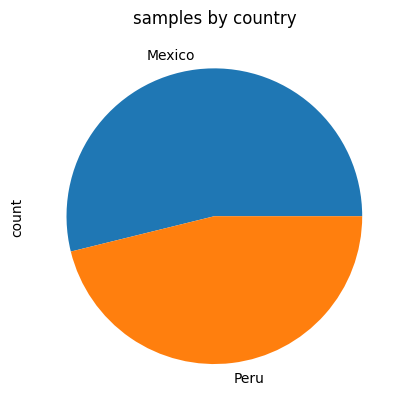

In [ ]:
country_latam_freqs.plot.pie(title='samples by country');

## Shotgun metagenomics ( 10 min - 8:37)

[**Shotgun sequencing**](https://en.wikipedia.org/wiki/Shotgun_sequencing) randomly sequences all DNA fragments in a biological sample, rather than targeting a specific DNA region as amplicon sequencing does. [Shotgun metagenomics](https://en.wikipedia.org/wiki/Shotgun_sequencing#Metagenomic_shotgun_sequencing), or whole-metagenomic shotgun (WMS) sequencing, or simply "[metagenomics](https://en.wikipedia.org/wiki/Metagenomics)", is the application of shotgun sequencing to recover DNA sequences from all microorganisms in a habitat.

Compared with 16S rRNA sequencing, shotgun metagenomics delivers higher resolution (usually down to species- or even strain-level), informs function in addition to composition, and includes all domains of life (including viruses and eukaryotes) rather than just prokaryotes, despite being more expensive, and more challenging in bioinformatic analysis.


The basic data table is `ogu.biom`. This table was generated by aligning sequencing reads against the Web of Life 2 (**WoL2**) reference genome database ([Zhu et al., 2019](https://www.nature.com/articles/s41467-019-13443-4)), and quantifying the number of reads mapped to each reference genome. The database files are available at: https://ftp.microbio.me/pub/wol2/

### Abundances of microbial OGUs

In [ ]:
from skbio import Table

The table latam_ogu.biom contains microbiome taxonomic profiles, specifically, the abundances of microbial OGUs (Operational Genomic Units) across samples.

In [ ]:
latamogu_path = github_data_path + "shotgun/latam_ogu.biom"
latam_ogu = Table.read(latamogu_path)
latam_ogu

14933 x 68 <class 'biom.table.Table'> with 90562 nonzero entries (8% dense)

It converts the BIOM table latam_ogu into a DataFrame (latam_df), making it easier to inspect and manipulate microbiome abundance data using standard pandas operations.

In [ ]:
latam_df = latam_ogu.to_dataframe()
# show dataframe DataFrame
latam_df.head()  # It shows the first rows

,13114.jensen.43.s012,13114.jensen.43.s013,13114.jensen.43.s014,13114.pinto.63.s001,13114.pinto.63.s002,13114.pinto.63.s003,13114.pinto.63.s004,13114.pinto.63.s005,13114.pinto.63.s006,13114.pinto.63.s007,...,13114.stewart.26.s006,13114.stewart.26.s007,13114.stewart.26.s008,13114.zaneveld.9.s004,13114.zaneveld.9.s005,13114.zaneveld.9.s006,13114.zaneveld.9.s010,13114.zaneveld.9.s011,13114.zaneveld.9.s012,13114.zaneveld.9.s022
G000005825,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G000006175,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G000006605,0,0,0,0,0,0,0,0,0,0,...,0,0,6.0,0,0,0,0,0,0,0
G000006725,0,1.0,0,0,0,0,0,0,70.0,0,...,0,0,0,0,0,0,0,0,0,0
G000006745,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
G902826025,23.0,1.0,0,0,0,0,0,0,0,0,...,3.0,9.0,4.0,0,0,0,0,0,0,5.0
G902826465,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G902826605,1.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
G902827015,0,0,2.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Each feature represents a reference genome. They are referred to as the operational genomic units (OGUs) [Zhu et al., 2022](journals.asm.org/doi/full/10.1128/msystems.00167-22), a term indicating that they are not the exact genomes that are present in the sample, but are reference genomes to which sequencing data can be mapped to. The true members of the microbial community may be closely related to those reference strains.


In [ ]:
latam_ogu.get_table_density()

0.0891846325351275

The shotgun metagenomics data has a sparsity of around 8–9%. This level of sparsity is expected and reflects the nature of the sequencing method. Shotgun sequencing captures all genomic content, including bacteria, archaea, viruses, and functional genes. This broader coverage results in richer datasets, with more features consistently detected across samples, leading to a significantly higher table density. As a result, shotgun data tends to be more comprehensive and less sparse than 16S rRNA-based datasets.

### Taxonomy

As shown above, there are over 400k features (OGUs) but merely 68 samples in the shotgun data table. Such a large number of features (referred to as [**high-dimensionality**](https://en.wikipedia.org/wiki/High-dimensional_statistics) in data science) imposes significant challenges to the subsequent analysis (you may read about the "[sesion of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality)" and intepretation. While there are pure mathematical approaches to mitigate high-dimensionality, biological sciences provide unique, knowledge-based solutions to it.

These features are not a plain list of entities. They are (presumably) microorganisms, and organisms can be classified. The classification of organisms, a.k.a., [**taxonomy**](https://en.wikipedia.org/wiki/Taxonomy), provides a hierarchical system with (usually) some 7-8 fixed ranks to describe the relationships among organisms.

The taxonomic classifications of the OGUs are provided in the ogu.tax file.

In [ ]:
latamtax_path = github_data_path + "shotgun/latam_ogu.tax"
latamtax_path

'https://raw.githubusercontent.com/nselem/biotraintemp/refs/heads/main/data/shotgun/latam_ogu.tax'

In [ ]:
tax_df = pd.read_csv(latamtax_path, sep='\t', low_memory=False, header=None,index_col=0)
tax_df

,1
0,
G000005825,d__Bacteria; p__Firmicutes; c__Bacilli; o__Bac...
G000006175,d__Archaea; p__Methanobacteriota_A; c__Methano...
G000006605,d__Bacteria; p__Actinobacteriota; c__Actinomyc...
G000006725,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
G000006745,d__Bacteria; p__Proteobacteria; c__Gammaproteo...
...,...
G902826025,d__Bacteria; p__Actinobacteriota; c__Acidimicr...
G902826465,d__Bacteria; p__Acidobacteriota; c__Vicinamiba...
G902826605,d__Bacteria; p__Acidobacteriota; c__Acidobacte...


Let's extract the phylum level from the taxonomy strings

In [ ]:
tax_df['Phylum'] = tax_df.iloc[:, 0].str.extract(r'p__([^;]+)')
tax_df

,1,Phylum
0,,
G000005825,d__Bacteria; p__Firmicutes; c__Bacilli; o__Bac...,Firmicutes
G000006175,d__Archaea; p__Methanobacteriota_A; c__Methano...,Methanobacteriota_A
G000006605,d__Bacteria; p__Actinobacteriota; c__Actinomyc...,Actinobacteriota
G000006725,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,Proteobacteria
G000006745,d__Bacteria; p__Proteobacteria; c__Gammaproteo...,Proteobacteria
...,...,...
G902826025,d__Bacteria; p__Actinobacteriota; c__Acidimicr...,Actinobacteriota
G902826465,d__Bacteria; p__Acidobacteriota; c__Vicinamiba...,Acidobacteriota
G902826605,d__Bacteria; p__Acidobacteriota; c__Acidobacte...,Acidobacteriota


In [ ]:
ranks = ['Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species']

Add phylum classifications from tax_df to latam_df, enabling analysis at the phylum level.

In [ ]:
latam_df['Phylum'] = tax_df['Phylum']
latam_df['Phylum']

,Phylum
G000005825,Firmicutes
G000006175,Methanobacteriota_A
G000006605,Actinobacteriota
G000006725,Proteobacteria
G000006745,Proteobacteria
...,...
G902826025,Actinobacteriota
G902826465,Acidobacteriota
G902826605,Acidobacteriota
G902827015,Proteobacteria


Making groups the OGU abundance data by phylum and sums the abundances across all samples, producing total abundances for each phylum

In [ ]:
df_phylum = latam_df.groupby('Phylum').sum()
df_phylum

,13114.jensen.43.s012,13114.jensen.43.s013,13114.jensen.43.s014,13114.pinto.63.s001,13114.pinto.63.s002,13114.pinto.63.s003,13114.pinto.63.s004,13114.pinto.63.s005,13114.pinto.63.s006,13114.pinto.63.s007,...,13114.stewart.26.s006,13114.stewart.26.s007,13114.stewart.26.s008,13114.zaneveld.9.s004,13114.zaneveld.9.s005,13114.zaneveld.9.s006,13114.zaneveld.9.s010,13114.zaneveld.9.s011,13114.zaneveld.9.s012,13114.zaneveld.9.s022
Phylum,,,,,,,,,,,,,,,,,,,,,
AABM5-125-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Acidobacteriota,94.0,58.0,26.0,64.0,268.0,276.0,358.0,631.0,718.0,190.0,...,270.0,9.0,4523.0,54.0,83.0,55.0,11.0,2.0,34.0,2.0
Actinobacteriota,717.0,265.0,139.0,760.0,414.0,1897.0,3216.0,3585.0,2697.0,2945.0,...,16804.0,152630.0,153761.0,896.0,1366.0,984.0,100.0,52.0,276.0,154681.0
Aerophobota,0,0,0,0,0,0,0,0,0,0,...,0,0,11.0,0,0,0,0,0,0,0
Altiarchaeota,0,2.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UBA9089,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
UBP14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Verrucomicrobiota,86.0,32.0,41.0,4.0,26.0,1.0,13.0,3.0,43.0,13.0,...,1524.0,6095.0,9667.0,29.0,49.0,26.0,1.0,0,4.0,69604.0


To create a mapping between each sample and its associated empo_2 environment classification, allowing for environment-based analysis.

In [ ]:
sample_to_empo = latam_samples['empo_2']
sample_to_empo

,empo_2
sample_name,
13114.jensen.43.s012,Saline
13114.jensen.43.s013,Saline
13114.jensen.43.s014,Saline
13114.rohwer.86.s001,Saline
13114.rohwer.86.s002,Saline
13114.rohwer.86.s003,Saline
13114.schmidt.56.s015,Non-saline
13114.schmidt.56.s016,Non-saline
13114.schmidt.56.s017,Non-saline


Transpose the df_phylum DataFrame so that the samples are arranged as rows instead of columns.

In [ ]:
df_phylum_T = df_phylum.T
df_phylum_T

Phylum,AABM5-125-24,Acidobacteriota,Actinobacteriota,Aerophobota,Altiarchaeota,Aquificota,Armatimonadota,Asgardarchaeota,Atribacterota,Aureabacteria,...,Thermotogota,UBA10199,UBA6262,UBA8248,UBA8481,UBA9089,UBP14,Verrucomicrobiota,WOR-3,Zixibacteria
13114.jensen.43.s012,0,94.0,717.0,0,0,0,0,0,0,0,...,0,2.0,0,1.0,0,0,0,86.0,0,0
13114.jensen.43.s013,0,58.0,265.0,0,2.0,0,0,13.0,0,0,...,0,0,0,0,0,0,0,32.0,0,2.0
13114.jensen.43.s014,0,26.0,139.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,41.0,0,0
13114.pinto.63.s001,0,64.0,760.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4.0,0,0
13114.pinto.63.s002,0,268.0,414.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,26.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13114.zaneveld.9.s006,0,55.0,984.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,26.0,0,0
13114.zaneveld.9.s010,0,11.0,100.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1.0,0,0
13114.zaneveld.9.s011,0,2.0,52.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
13114.zaneveld.9.s012,0,34.0,276.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,4.0,0,0


Add the empo_2 environment classification information as a new column to the transposed df_phylum_T DataFrame.

In [ ]:
df_phylum_T['empo_2'] = sample_to_empo
df_phylum_T

Phylum,AABM5-125-24,Acidobacteriota,Actinobacteriota,Aerophobota,Altiarchaeota,Aquificota,Armatimonadota,Asgardarchaeota,Atribacterota,Aureabacteria,...,UBA10199,UBA6262,UBA8248,UBA8481,UBA9089,UBP14,Verrucomicrobiota,WOR-3,Zixibacteria,empo_2
13114.jensen.43.s012,0,94.0,717.0,0,0,0,0,0,0,0,...,2.0,0,1.0,0,0,0,86.0,0,0,Saline
13114.jensen.43.s013,0,58.0,265.0,0,2.0,0,0,13.0,0,0,...,0,0,0,0,0,0,32.0,0,2.0,Saline
13114.jensen.43.s014,0,26.0,139.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,41.0,0,0,Saline
13114.pinto.63.s001,0,64.0,760.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4.0,0,0,NaN
13114.pinto.63.s002,0,268.0,414.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,26.0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13114.zaneveld.9.s006,0,55.0,984.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,26.0,0,0,NaN
13114.zaneveld.9.s010,0,11.0,100.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1.0,0,0,NaN
13114.zaneveld.9.s011,0,2.0,52.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,NaN
13114.zaneveld.9.s012,0,34.0,276.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,4.0,0,0,NaN


Group the data by the empo_2 environmental categories and sum the abundances within each group. Then transpose the result so that phyla are rows again, making it easier to compare abundances across environments.

In [ ]:
df_grouped = df_phylum_T.groupby('empo_2').sum().T  # Return to phylum as rows
df_grouped

empo_2,Non-saline,Saline
Phylum,,
AABM5-125-24,1.0,1.0
Acidobacteriota,8942.0,25037.0
Actinobacteriota,147840.0,984171.0
Aerophobota,0,22.0
Altiarchaeota,1.0,2.0
...,...,...
UBA9089,0,0
UBP14,0,0
Verrucomicrobiota,3540.0,55983.0


Identify the 10 phyla with the highest total abundance across all environmental groups, then select and display only those top 10 phyla for further analysis.

In [ ]:
top10_phyla = df_grouped.sum(axis=1).nlargest(10).index
df_top10 = df_grouped.loc[top10_phyla]
df_top10

empo_2,Non-saline,Saline
Phylum,,
Proteobacteria,160531.0,4215030.0
SAR324,0,3758806.0
Thermoproteota,2191.0,1380734.0
Actinobacteriota,147840.0,984171.0
Thermoplasmatota,2.0,1029171.0
Marinisomatota,0,1006565.0
Cyanobacteria,109873.0,700739.0
Bacteroidota,17536.0,330560.0
Chloroflexota,2393.0,286941.0


Convert the absolute abundances of the top 10 phyla into relative abundances within each empo_2 group by dividing each phylum’s count by the total counts in that group

In [ ]:
df_rel = df_top10.div(df_top10.sum(axis=0), axis=1)
df_rel

empo_2,Non-saline,Saline
Phylum,,
Proteobacteria,0.364489,0.304764
SAR324,0.0,0.271777
Thermoproteota,0.004975,0.099833
Actinobacteriota,0.335674,0.071159
Thermoplasmatota,0.000005,0.074413
Marinisomatota,0.0,0.072779
Cyanobacteria,0.249469,0.050666
Bacteroidota,0.039816,0.023901
Chloroflexota,0.005433,0.020747


Plot a stacked bar chart showing the relative abundances of the top 10 phyla across different empo_2 environment groups. The plot includes axis labels, a title, and a legend positioned outside the plot for clarity.

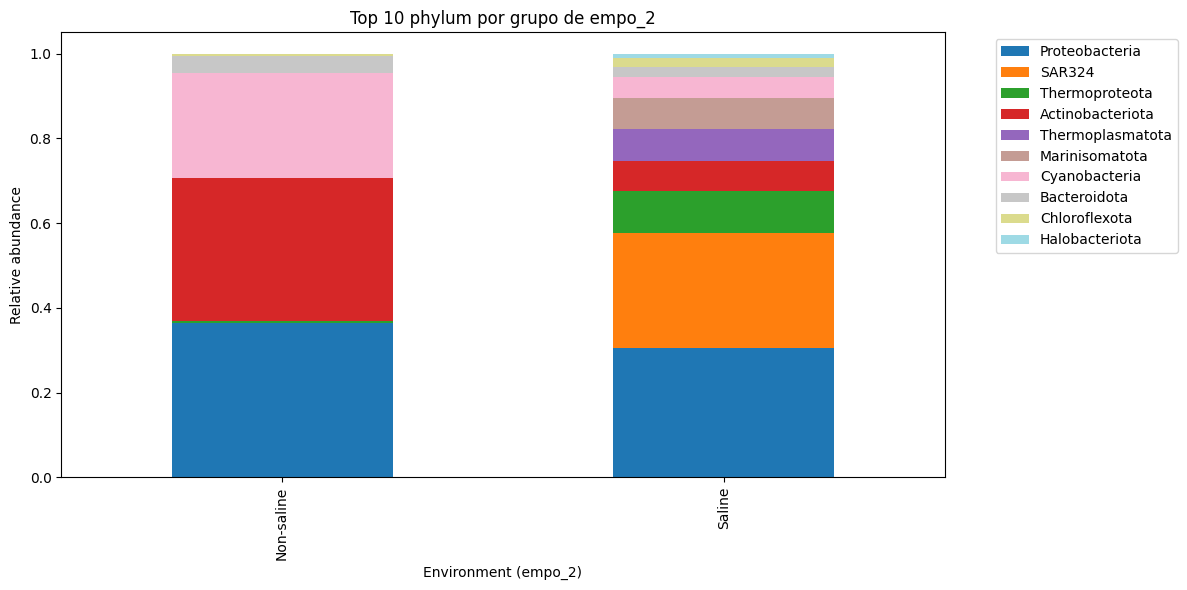

In [ ]:
df_rel.T.plot(kind='bar', stacked=True, figsize=(12,6), colormap='tab20')
plt.ylabel("Relative abundance")
plt.xlabel("Environment (empo_2)")
plt.title("Top 10 phylum por grupo de empo_2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

We can see in the saline samples the group SAR324 which is the name of a bacterial phylum, specifically a candidate phylum, which means it hasn't yet been fully isolated or characterized in the lab, but is known from environmental sequencing data.

The name "SAR" comes from a broader supergroup including Stramenopiles, Alveolates, and Rhizaria. The number 324 refers to the specific group detected in environmental samples—especially from ocean water—during early sequencing studies. SAR324 is part of the "microbial dark matter," which includes microbes that we know exist based on genetic data, but haven't yet been cultivated.

Where is SAR324 found?
In deep ocean waters, In oxygen minimum zones (OMZs), Sometimes in marine sediments

Why is it important?
Genomic evidence suggests that SAR324 may play key roles in global biogeochemical cycles, particularly in the carbon and sulfur cycles, based on the presence of genes related to these metabolic pathways in its genomes. [Delta-proteobacterial SAR324 group in hydrothermal plumes on the South Mid-Atlantic Ridge](https://https://doi.org/10.1038/srep22842)


### Phylogeny (optional 3 min)

As a classification method, taxonomy is descriptive, operational but coarse. The 7-8 standard taxonomic ranks may fall short in resolving the ever increasing number of discovered organisms (there are now more than 2 million microbial genomes in NCBI). To capture the relationships among microbes with finer resolution, one may resort to phylogeny instead.

A [**phylogenetic tree**](https://en.wikipedia.org/wiki/Phylogenetic_tree) is a graph that describes the evolutionary relationships among organisms. All (cellular) organisms descend from a common ancestor. Therefore a tree structure from a root to many tips can unite them all. The phylogenetic tree not only contains the branching pattern (**topology**) indicating the order of speciation, but also provides **branch lengths** indicating the amount of evolution accumulated within each lineage. Therefore, phylogeny is suitable for modeling microbial feature relations in a quantitative manner.

The WoL2 reference phylogeny is provided by `ogu.nwk`. It is a [Newick](https://en.wikipedia.org/wiki/Newick_format)-formatted file. One can read it using scikit-bio's [`TreeNode`](https://scikit.bio/docs/latest/generated/skbio.tree.TreeNode.html) class.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
from skbio import TreeNode

Constructs the full path to the Newick tree file and displays its content.

In [ ]:
latamtree_path = github_data_path + "shotgun/latam_ogu.nwk"

Loads a phylogenetic tree of OGUs from a Newick file into a TreeNode object for further phylogenetic analysis

In [ ]:
tree_latam = TreeNode.read(latamtree_path)
tree_latam

Due to the large size of the tree, we can't display it in full. Instead, we'll locate an arbitrary tip (the first OGU in the list, '**G000005825**'), trace its lineage up to the grandparent node, and visualize a small clade descending from that point.

In [ ]:
print(tree_latam.find('G000005825').parent.parent.ascii_art())

As the tree is quite large. Now that we have generated the latam_samples.tsv (metadata) and latam_ogu.nwk (phylogenetic tree), which can be used in [microreact](https://microreact.org/). It is a free, interactive platform that allows you to explore phylogenetic trees alongside sample metadata. By uploading the .tsv and .nwk files, you can dynamically investigate relationships, clusters, and patterns across the Latin American samples. This is especially helpful for large datasets, as it enhances data interpretation, interactivity, and communication of results.

Folowing the link you can see the tree in microreact https://microreact.org/project/bXyNWcLQZsAVsVFvuDVYr8-emp500-latino-america

## Self evaluation poll (10 min - 8:47)

This short assessment will help reinforce your understanding and prepare you for further analysis and integration tasks in microbiome research.

📌 Click the link below to begin the quiz: 👉  [Poll link, Quiz 1](https://pollev.com/biotrainaicabana135)

1. Select “**Skip for now**” when prompted to log in.

2. Enter **your name** to join as a participant.

3. **Select all correct answers** — some questions may have multiple correct options.

4. You can review your **results** at the end of the quiz.